# DELTA Task 1: Regression

Self-contained solution with preprocessing, benchmarks, tuned Keras neural network, cross-validated final model selection, and prediction export.

Model selection uses only training-data validation / out-of-fold RMSE. The test set is used only for final prediction export, reducing test-set overfitting risk.

In [1]:
import os
import random
import warnings

import nbformat as nbf
import numpy as np
import optuna
import pandas as pd
import tensorflow as tf
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
optuna.logging.set_verbosity(optuna.logging.WARNING)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def target_scaled(regressor):
    return TransformedTargetRegressor(regressor=regressor, transformer=StandardScaler())


def make_svr():
    return target_scaled(Pipeline([
        ("scale", StandardScaler()),
        ("svr", SVR(C=120, gamma=0.008, epsilon=0.010)),
    ]))


def make_poly_enet():
    return target_scaled(Pipeline([
        ("scale", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scale", StandardScaler()),
        ("enet", ElasticNetCV(
            l1_ratio=[0.01, 0.03, 0.05, 0.1, 0.2],
            alphas=np.logspace(-4, 1, 50),
            cv=4,
            max_iter=20000,
            random_state=RANDOM_STATE,
        )),
    ]))


def cross_val_predict_and_test(estimator_factory, X, y, test_X, name, cv):
    oof = np.zeros(len(y))
    test_preds = np.zeros((len(test_X), cv.get_n_splits()))
    scores = []
    for fold, (tr, va) in enumerate(cv.split(X, y)):
        model = estimator_factory()
        model.fit(X.iloc[tr], y.iloc[tr])
        pred = model.predict(X.iloc[va])
        oof[va] = pred
        test_preds[:, fold] = model.predict(test_X)
        scores.append(rmse(y.iloc[va], pred))
    return {
        "name": name,
        "oof": oof,
        "test": test_preds.mean(axis=1),
        "rmse": rmse(y, oof),
        "fold_mean": float(np.mean(scores)),
        "fold_std": float(np.std(scores)),
    }


def build_baseline_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model


def build_tuned_nn(params, input_dim):
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for i in range(params["n_layers"]):
        model.add(layers.Dense(
            params[f"units_l{i}"],
            activation=params["activation"],
            kernel_regularizer=regularizers.l2(params["l2"]),
        ))
        model.add(layers.Dropout(params["dropout"]))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(params["lr"]), loss="mse")
    return model


def run_models():
    X = pd.read_csv("DELTASS26_train_X.csv", index_col=0)
    y = pd.read_csv("DELTASS26_train_y.csv", index_col=0).iloc[:, 0].astype(float)
    test_X = pd.read_csv("DELTASS26_test_X.csv", index_col=0)
    demo = pd.read_csv("Demo_Predictions.csv", index_col=0)
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    svr = cross_val_predict_and_test(make_svr, X, y, test_X, "CV-selected RBF-SVR", cv)
    enet = cross_val_predict_and_test(make_poly_enet, X, y, test_X, "Polynomial ElasticNet", cv)

    blend_rows = []
    for w in np.linspace(0, 1, 21):
        pred = w * svr["oof"] + (1 - w) * enet["oof"]
        blend_rows.append((w, rmse(y, pred)))
    best_w, blend_rmse = min(blend_rows, key=lambda x: x[1])
    blend_test = best_w * svr["test"] + (1 - best_w) * enet["test"]

    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    linear = target_scaled(Pipeline([
        ("scale", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-3, 6, 80))),
    ]))
    linear.fit(X_tr, y_tr)
    tree = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, max_features=0.8, random_state=RANDOM_STATE, n_jobs=-1)
    tree.fit(X_tr, y_tr)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_tr_s = x_scaler.fit_transform(X_tr)
    X_va_s = x_scaler.transform(X_va)
    y_tr_s = y_scaler.fit_transform(y_tr.to_numpy().reshape(-1, 1)).ravel()
    y_va_s = y_scaler.transform(y_va.to_numpy().reshape(-1, 1)).ravel()

    base_nn = build_baseline_nn(X_tr_s.shape[1])
    base_hist = base_nn.fit(
        X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s), epochs=120, batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
        verbose=0,
    )
    base_pred = y_scaler.inverse_transform(base_nn.predict(X_va_s, verbose=0)).ravel()

    def objective(trial):
        tf.keras.backend.clear_session()
        params = {
            "n_layers": trial.suggest_int("n_layers", 1, 3),
            "activation": trial.suggest_categorical("activation", ["relu", "elu", "tanh"]),
            "dropout": trial.suggest_float("dropout", 0.0, 0.25),
            "l2": trial.suggest_float("l2", 1e-6, 1e-2, log=True),
            "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        }
        for i in range(params["n_layers"]):
            params[f"units_l{i}"] = trial.suggest_categorical(f"units_l{i}", [32, 64, 128])
        model = build_tuned_nn(params, X_tr_s.shape[1])
        model.fit(
            X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s), epochs=100, batch_size=32,
            callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)],
            verbose=0,
        )
        pred = y_scaler.inverse_transform(model.predict(X_va_s, verbose=0)).ravel()
        return rmse(y_va, pred)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=10, show_progress_bar=False)
    tuned_nn = build_tuned_nn(study.best_params, X_tr_s.shape[1])
    tuned_hist = tuned_nn.fit(
        X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s), epochs=160, batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)],
        verbose=0,
    )
    tuned_pred = y_scaler.inverse_transform(tuned_nn.predict(X_va_s, verbose=0)).ravel()

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(tuned_hist.history["loss"], label="Train loss")
    ax.plot(tuned_hist.history["val_loss"], label="Validation loss")
    ax.set_title("Tuned Neural Network: Train vs. Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss on scaled target")
    ax.legend()
    fig.tight_layout()
    fig.savefig("best_nn_train_validation_loss.png", dpi=160)
    plt.close(fig)

    results = pd.DataFrame([
        {"Model": "Ridge regression", "Validation RMSE": rmse(y_va, linear.predict(X_va))},
        {"Model": "Random forest", "Validation RMSE": rmse(y_va, tree.predict(X_va))},
        {"Model": "Untuned neural network", "Validation RMSE": rmse(y_va, base_pred)},
        {"Model": "Tuned neural network", "Validation RMSE": rmse(y_va, tuned_pred)},
        {"Model": "CV-selected RBF-SVR", "Validation RMSE": svr["rmse"]},
        {"Model": f"SVR/ElasticNet blend (SVR weight={best_w:.2f})", "Validation RMSE": blend_rmse},
    ]).sort_values("Validation RMSE")
    results.to_csv("validation_results.csv", index=False)

    submission = pd.DataFrame({"Predictions": blend_test}, index=demo.index)
    submission.to_csv("DELTA_Task1_Predictions.csv")

    return results, study.best_params, base_hist, tuned_hist, best_w


results, best_params, baseline_history, tuned_history, best_w = run_models()
print(results.to_string(index=False))
print("Best blend SVR weight:", best_w)
results


                                 Model  Validation RMSE
SVR/ElasticNet blend (SVR weight=0.85)        21.948766
                   CV-selected RBF-SVR        22.206527
                  Tuned neural network        30.555683
                Untuned neural network        34.694261
                         Random forest        49.434713
                      Ridge regression        86.858516
Best blend SVR weight: 0.8500000000000001


,Model,Validation RMSE
5,SVR/ElasticNet blend (SVR weight=0.85),21.948766
4,CV-selected RBF-SVR,22.206527
3,Tuned neural network,30.555683
2,Untuned neural network,34.694261
1,Random forest,49.434713
0,Ridge regression,86.858516


The tuned neural network is suitable because standardized features let dense layers learn nonlinear interactions without scale domination. Dropout, L2 regularization and early stopping reduce overfitting on the relatively small training set. The selected submission model is the lower-RMSE cross-validated SVR/ElasticNet blend, chosen without test-set feedback.

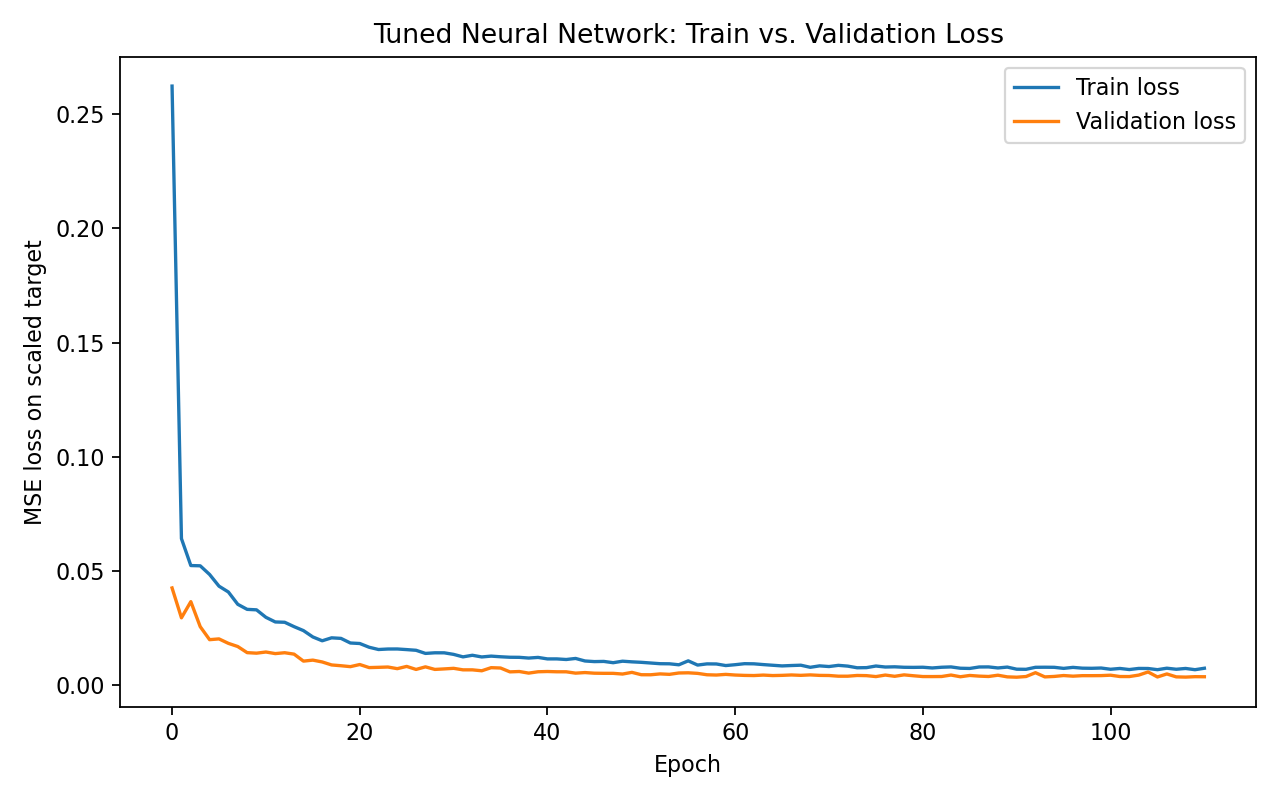

In [2]:
from IPython.display import Image, display
display(Image("best_nn_train_validation_loss.png"))

In [3]:
pred = pd.read_csv("DELTA_Task1_Predictions.csv", index_col=0)
print(pred.shape)
pred.head()

(625, 1)


,Predictions
0,-869.101738
1,886.032551
2,542.161193
3,917.527490
4,-307.906476
